--- 1. Logistic Regression (Temel Model) ---
Accuracy: 0.7142857142857143
F1-Score (Macro): 0.6735658914728683

--- 2. Random Forest Classifier (Temel Model) ---
Accuracy: 0.7571428571428571
F1-Score (Macro): 0.7338198890311566


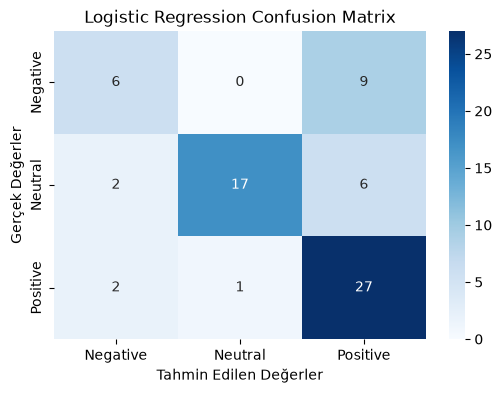

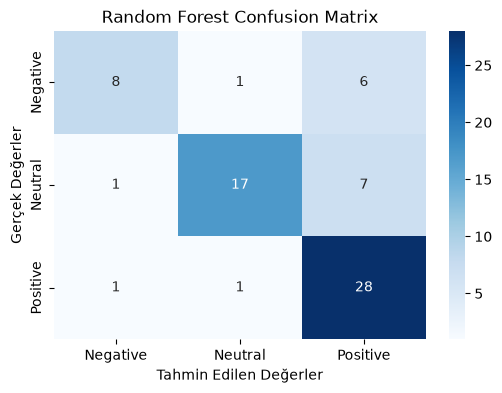


--- Random Forest GridSearch Optimizasyonu ---
En İyi Parametreler: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Optimizasyon Sonrası Yeni Accuracy: 0.7571428571428571
Optimizasyon Sonrası Yeni F1-Score (Macro): 0.7338198890311566

En iyi Random Forest modeli 'sentiment_model.pkl' olarak başarıyla kaydedildi!


In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


df = pd.read_csv('../data/processed/nlp_processed_reviews.csv')

df.dropna(subset=['processed_text', 'sentiment'], inplace=True)

X = df['processed_text']
y = df['sentiment']

# 2. Vektörizasyon (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000) 
X_tfidf = tfidf.fit_transform(X)


joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')


X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# MODEL 1: LOGISTIC REGRESSION (BASE)
# ==========================================
print("--- 1. Logistic Regression (Temel Model) ---")
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
lr_preds = lr_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_preds))
print("F1-Score (Macro):", f1_score(y_test, lr_preds, average='macro'))

# ==========================================
# MODEL 2: RANDOM FOREST (BASE)
# ==========================================
print("\n--- 2. Random Forest Classifier (Temel Model) ---")
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
rf_preds = rf_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_preds))
print("F1-Score (Macro):", f1_score(y_test, rf_preds, average='macro'))

# ==========================================
# CONFUSION MATRIX GÖRSELLEŞTİRMESİ
# ==========================================
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['Negative', 'Neutral', 'Positive'])
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Neutral', 'Positive'], 
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.ylabel('Gerçek Değerler')
    plt.xlabel('Tahmin Edilen Değerler')
    plt.show()

plot_confusion_matrix(y_test, lr_preds, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(y_test, rf_preds, "Random Forest Confusion Matrix")

# ==========================================
# HİPERPARAMETRE OPTİMİZASYONU (GRID SEARCH)
# ==========================================


print("\n--- Random Forest GridSearch Optimizasyonu ---")

param_grid_rf = {
    'n_estimators': [100, 200],       
    'max_depth': [None, 20, 50],      
    'min_samples_split': [2, 5]      
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), 
                              param_grid_rf, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
best_preds = best_rf.predict(X_test)

print("En İyi Parametreler:", grid_search_rf.best_params_)
print("Optimizasyon Sonrası Yeni Accuracy:", accuracy_score(y_test, best_preds))
print("Optimizasyon Sonrası Yeni F1-Score (Macro):", f1_score(y_test, best_preds, average='macro'))

joblib.dump(best_rf, '../models/sentiment_model.pkl')
print("\nEn iyi Random Forest modeli 'sentiment_model.pkl' olarak başarıyla kaydedildi!")

Analiz sonucunda Random Forest algoritması Logistic Regression'ı geride bırakmıştır. Bunun temel nedeni, TF-IDF ile oluşturulan özellik uzayında bazı kelimelerin tek başlarına değil, ancak belirli kelime gruplarıyla bir araya geldiklerinde (örneğin "şarj" ve "çabuk bitiyor") bir anlam ifade etmesidir. Random Forest'ın karar ağaçları, özellikler (kelimeler) arasındaki bu doğrusal olmayan (non-linear) karmaşık etkileşimleri yakalamakta çok daha başarılıdır. Ayrıca, hiperparametre optimizasyonu ile ağaç derinliği kontrol altına alınarak modelin yüksek boyutlu veriyi ezberlemesi (overfitting) engellenmiştir.